# Q2: Is there a stat-based type hierarchy?

**Question:** Are some Pokemon types simply statistically stronger than others, and is there an
offense/defense tradeoff by type?

Sub-questions:
- Which types have the highest/lowest average total stats?
- Do "rarer" types (fewer Pokemon) tend to be stronger, i.e. is rarity linked to power?
- Is there a visible offense-vs-defense tradeoff across types, or do strong types just win on both?
- Which types are the most/least consistent (variance in total stats)?

Note: a dual-type Pokemon (e.g. Grass/Poison) counts toward the average for *both* of its types --
this is a type-level view, not a partition of Pokemon.


## 1. Setup & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
%matplotlib inline

pokemon = pd.read_csv("data/pokemon.csv")
types = pd.read_csv("data/types.csv")

stat_cols = ["hp", "attack", "defense", "special-attack", "special-defense", "speed"]
pokemon["total_stats"] = pokemon[stat_cols].sum(axis=1)

type_stats = types.merge(pokemon[["id", "total_stats"] + stat_cols], left_on="pokemon_id", right_on="id")
type_stats.head()


,pokemon_id,type_id,pokemon_name,type_name,id,total_stats,hp,attack,defense,special-attack,special-defense,speed
0,1,12,bulbasaur,grass,1,318,45,49,49,65,65,45
1,1,4,bulbasaur,poison,1,318,45,49,49,65,65,45
2,2,12,ivysaur,grass,2,405,60,62,63,80,80,60
3,2,4,ivysaur,poison,2,405,60,62,63,80,80,60
4,3,12,venusaur,grass,3,525,80,82,83,100,100,80


## 2. Average stats by type

In [2]:
type_summary = (
    type_stats.groupby("type_name", observed=True)[["total_stats"] + stat_cols]
    .mean()
    .sort_values("total_stats", ascending=False)
)
type_summary["offense"] = type_summary["attack"] + type_summary["special-attack"]
type_summary["defense_total"] = type_summary["defense"] + type_summary["special-defense"]
type_summary.round(1)


,total_stats,hp,attack,defense,special-attack,special-defense,speed,offense,defense_total
type_name,,,,,,,,,
dragon,558.8,89.7,100.2,91.3,101.8,89.6,86.1,202.1,180.9
steel,505.2,72.8,98.2,108.8,77.2,83.0,65.2,175.4,191.8
fighting,504.9,79.5,112.6,84.6,68.2,76.3,83.7,180.8,160.9
psychic,492.6,74.9,75.6,77.5,97.2,89.0,78.4,172.8,166.5
fire,476.5,72.5,86.2,73.2,91.7,75.7,77.2,178.0,148.9
dark,475.9,75.6,97.0,73.7,76.2,72.9,80.4,173.3,146.6
ice,473.8,81.6,90.3,80.1,75.7,76.7,69.5,166.0,156.7
fairy,465.6,68.4,73.2,76.8,86.2,90.2,70.8,159.5,167.0
flying,462.8,71.9,82.7,70.4,78.2,73.4,86.3,160.9,143.8


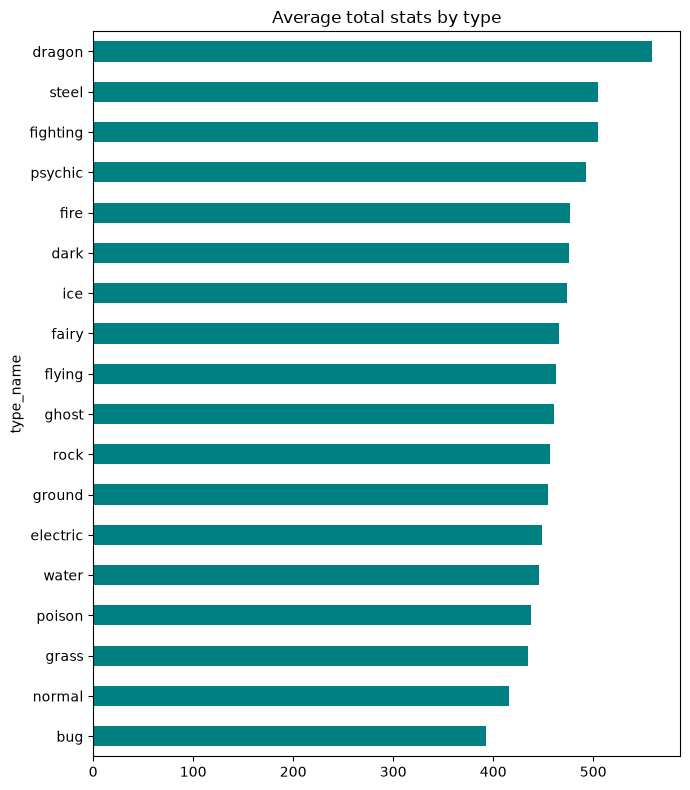

In [3]:
type_summary["total_stats"].sort_values().plot(kind="barh", figsize=(7, 8), color="teal")
plt.title("Average total stats by type")
plt.tight_layout()


## 3. Does rarity correlate with power?

If a type has fewer Pokemon, is it (on average) a stronger type -- consistent with "rare = special" --
or is there no relationship?


Correlation (n_pokemon vs avg total_stats): -0.22


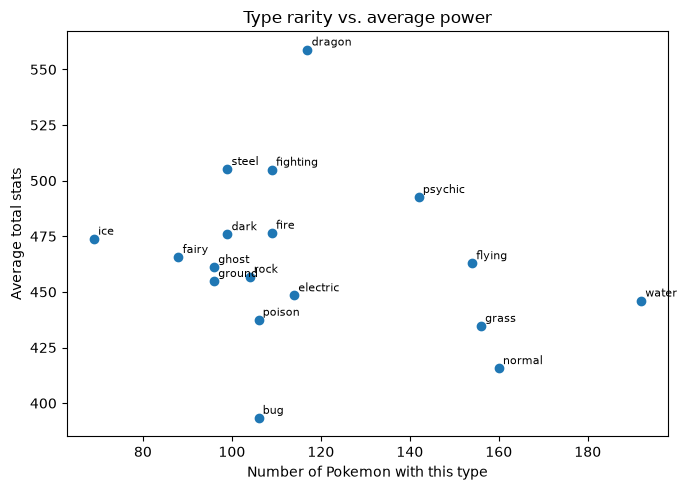

In [4]:
n_per_type = types["type_name"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(n_per_type.reindex(type_summary.index), type_summary["total_stats"])
for t in type_summary.index:
    ax.annotate(t, (n_per_type[t], type_summary.loc[t, "total_stats"]), fontsize=8,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Number of Pokemon with this type")
ax.set_ylabel("Average total stats")
ax.set_title("Type rarity vs. average power")
plt.tight_layout()

corr = np.corrcoef(n_per_type.reindex(type_summary.index), type_summary["total_stats"])[0, 1]
print(f"Correlation (n_pokemon vs avg total_stats): {corr:.2f}")


## 4. Offense vs. defense tradeoff by type

Plot each type's offensive total (attack + special-attack) against its defensive total
(defense + special-defense). A clean tradeoff would show a downward-sloping cloud; if strong
types just win on both axes, the cloud trends upward together instead.


Correlation (offense vs defense, across types): 0.60


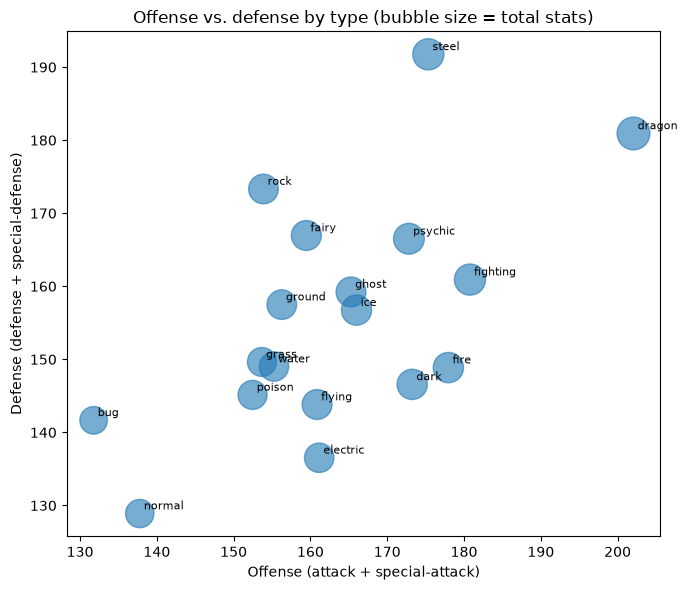

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(type_summary["offense"], type_summary["defense_total"], s=type_summary["total_stats"], alpha=0.6)
for t in type_summary.index:
    ax.annotate(t, (type_summary.loc[t, "offense"], type_summary.loc[t, "defense_total"]), fontsize=8,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Offense (attack + special-attack)")
ax.set_ylabel("Defense (defense + special-defense)")
ax.set_title("Offense vs. defense by type (bubble size = total stats)")
plt.tight_layout()

offense_defense_corr = type_summary[["offense", "defense_total"]].corr().iloc[0, 1]
print(f"Correlation (offense vs defense, across types): {offense_defense_corr:.2f}")


## 5. Which types are most/least consistent?

In [6]:
type_variance = type_stats.groupby("type_name", observed=True)["total_stats"].std().sort_values(ascending=False)
type_variance.to_frame("total_stats_std")


,total_stats_std
type_name,
dragon,136.182599
fairy,130.472643
poison,127.790884
psychic,127.524627
ground,124.036412
bug,121.734995
electric,118.625134
ice,115.457736
steel,114.864698


## 6. Takeaways

*(Numbers verified independently from the raw CSV.)*

- **There is a real hierarchy, and it's not small.** Average total stats range from
  **dragon (558.8)**, the strongest type, down to **bug (393.3)**, the weakest -- a 166-point
  gap, comparable to the entire legendary-vs-normal gap from Q1. Steel (505.2) and fighting
  (504.9) round out the top three.
- **Rarity is not the explanation -- if anything it runs the other way.** Correlation between
  "number of Pokemon with this type" and "average total stats" is **-0.22**: a weak *negative*
  relationship. Common types like water (192 Pokemon) and normal (160) sit mid-to-low on power;
  dragon, one of the rarer types, sits at the top. Power isn't being rationed by scarcity.
- **No clean offense/defense tradeoff -- strong types tend to win on both.** Dragon leads both
  offense (202.1) and defense (180.9). The types with the best defense totals (steel 191.8,
  dragon 180.9, fairy 167.0) are not systematically the weakest on offense -- there's no sharp
  "glass cannon vs. wall" split visible at the type-average level. Any such tradeoff exists
  Pokemon-by-Pokemon, not type-by-type.
- **Consistency varies a lot by type.** Dragon (std 136.2) and fairy (130.5) have the widest
  spread -- these types mix weak early-game Pokemon with top-tier legendaries/pseudo-legendaries.
  Rock (95.9) and fighting (108.2) are the most consistent -- picking a random rock-type tells you
  more about its likely power level than picking a random dragon-type does.
